# Phase 1: Customer Loan Data 



## 2. Dataset Description




In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [138]:
DATA_PATH = "Train data.csv"
df = pd.read_csv(DATA_PATH)
df.head()
df.drop("Loan_ID", axis=1, inplace=True)

In [139]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols.remove("Credit_History")
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
categorical_cols.append("Credit_History")
target_col = "Loan_Status"


print(f"  Numerical features: {numeric_cols}")
print(f"  Categorical features: {categorical_cols}")


  Numerical features: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
  Categorical features: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status', 'Credit_History']


## 3. Initial Data Checks




In [140]:
print("--- Missing values per column ---")
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({"missing_count": missing, "percent": missing_pct})
miss_df = miss_df[miss_df["missing_count"] > 0].sort_values("missing_count", ascending=False)
display(miss_df)

--- Missing values per column ---


,missing_count,percent
Credit_History,50,8.14
Self_Employed,32,5.21
LoanAmount,22,3.58
Dependents,15,2.44
Loan_Amount_Term,14,2.28
Gender,13,2.12
Married,3,0.49


In [141]:
print("\n--- Duplicate rows ---")
dup_rows = df.duplicated().sum()
print(f"Duplicate rows: {dup_rows}")



--- Duplicate rows ---
Duplicate rows: 0


In [142]:
print("\n--- Duplicate column names ---")
dup_cols = df.columns[df.columns.duplicated()].tolist()
print(f"Duplicate column names: {dup_cols }")


--- Duplicate column names ---
Duplicate column names: []


## 4. Categorical Variables Analysis




In [143]:
cat_for_eda = categorical_cols.copy()

print("Unique values per categorical column :")
for c in cat_for_eda:
    vals = df[c].dropna().unique().tolist()
    print(f"\n  {c}: {len(vals)}{sorted(vals, key=str)}")


Unique values per categorical column :

  Gender: 2['Female', 'Male']

  Married: 2['No', 'Yes']

  Dependents: 4['0', '1', '2', '3+']

  Education: 2['Graduate', 'Not Graduate']

  Self_Employed: 2['No', 'Yes']

  Property_Area: 3['Rural', 'Semiurban', 'Urban']

  Loan_Status: 2['N', 'Y']

  Credit_History: 2[0.0, 1.0]


In [144]:
def clean_categorical(series):
    s = series.astype(str).str.strip()
    s = s.replace({"nan": np.nan})
    return s

for c in cat_for_eda:
    df[c] = clean_categorical(df[c])


In [145]:

print(df[target_col].value_counts(dropna=False))
map_target = {"Y": 1, "N": 0}
df["Loan_Status_encoded"] = df[target_col].map(map_target)

print(df[[target_col, "Loan_Status_encoded"]].drop_duplicates().sort_values(target_col))


Loan_Status
Y    422
N    192
Name: count, dtype: int64
  Loan_Status  Loan_Status_encoded
1           N                    0
0           Y                    1


In [146]:
from sklearn.preprocessing import LabelEncoder


cat_for_eda = [c for c in cat_for_eda if c != target_col]

le_store = {}
for c in cat_for_eda:
    le = LabelEncoder()
    mode_val = df[c].mode()[0]
    col = df[c].fillna(mode_val)
    df[c + "_enc"] = le.fit_transform(col.astype(str))
    le_store[c] = le

encoded_cat_names = [c + "_enc" for c in cat_for_eda]




feature_cols_encoded = encoded_cat_names + numeric_cols
print("Encoded categorical columns (features only, target excluded):")
print(encoded_cat_names)


Encoded categorical columns (features only, target excluded):
['Gender_enc', 'Married_enc', 'Dependents_enc', 'Education_enc', 'Self_Employed_enc', 'Property_Area_enc', 'Credit_History_enc']


## 5. Exploratory Data Analysis




C:\Users\moham\AppData\Local\Temp\ipykernel_29776\232508038.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, order=order, palette="Set2", ax=ax)


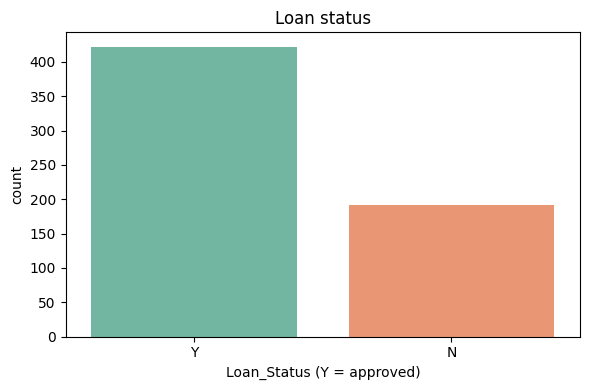

In [147]:
fig, ax = plt.subplots(figsize=(6, 4))
order = df[target_col].value_counts().index.tolist()
sns.countplot(data=df, x=target_col, order=order, palette="Set2", ax=ax)
ax.set_title("Loan status")
ax.set_xlabel("Loan_Status (Y = approved)")
plt.tight_layout()
plt.show()


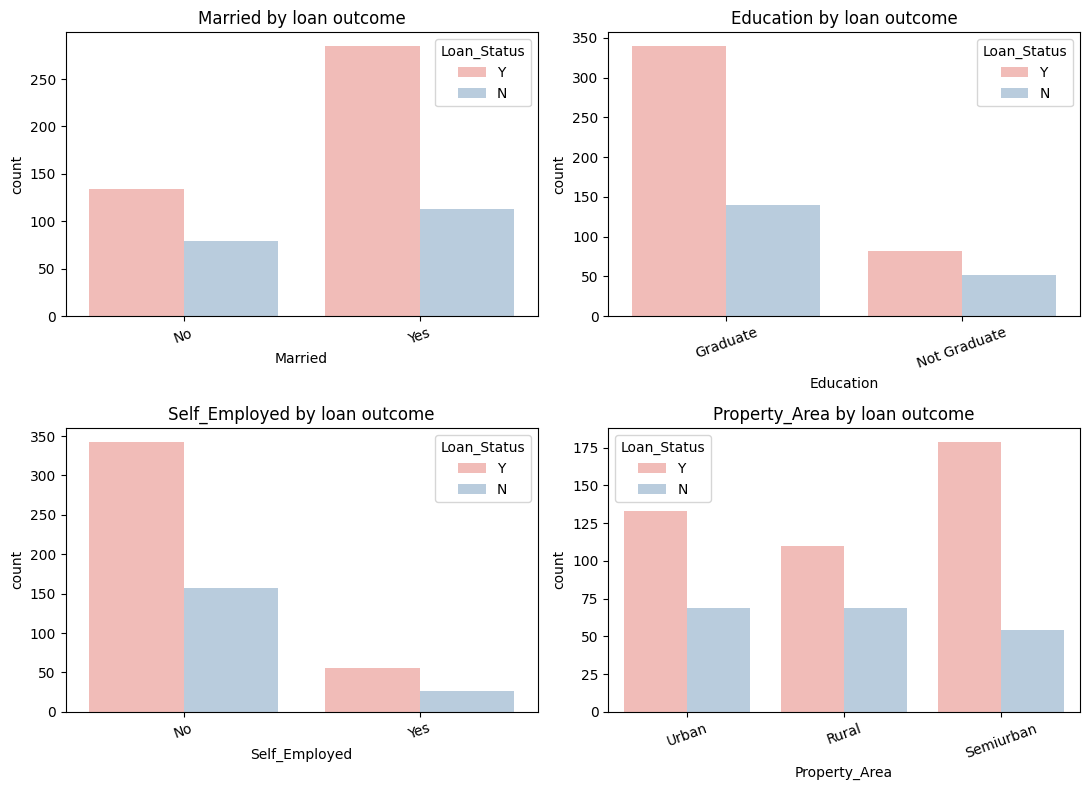

In [148]:
cats_plot = ["Married", "Education", "Self_Employed", "Property_Area"]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.ravel()
for ax, c in zip(axes, cats_plot):
    sns.countplot(data=df, x=c, hue=target_col, ax=ax, palette="Pastel1")
    ax.set_title(f"{c} by loan outcome")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


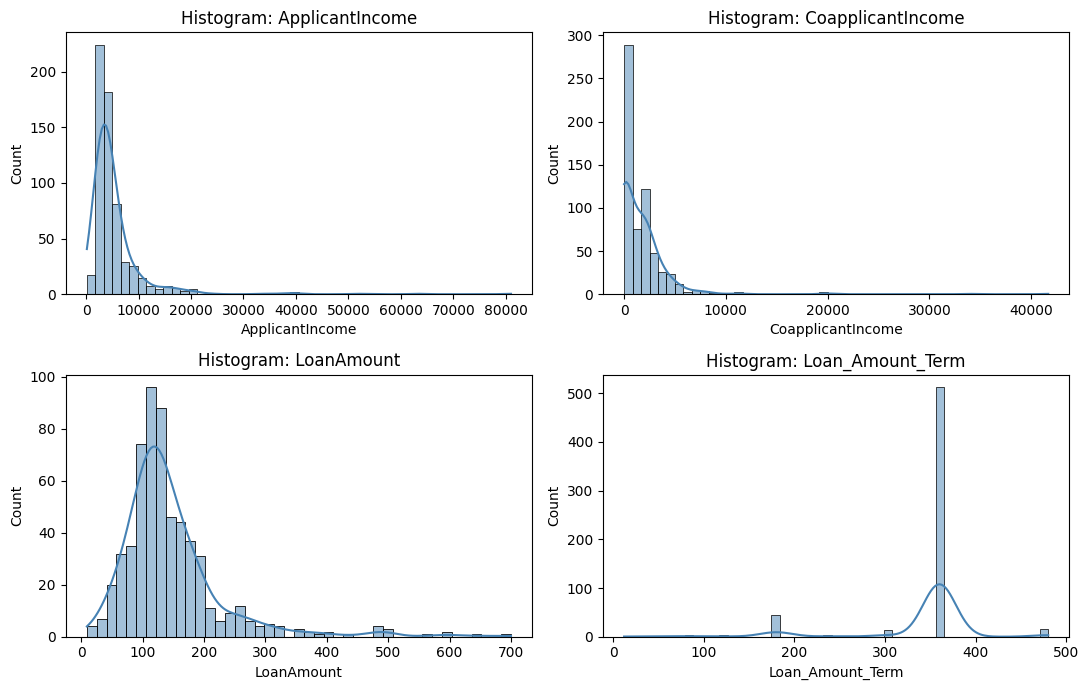

In [149]:
num_plot = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.ravel()
for ax, c in zip(axes, num_plot):
    sns.histplot(df[c].dropna(), kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Histogram: {c}")
plt.tight_layout()
plt.show()


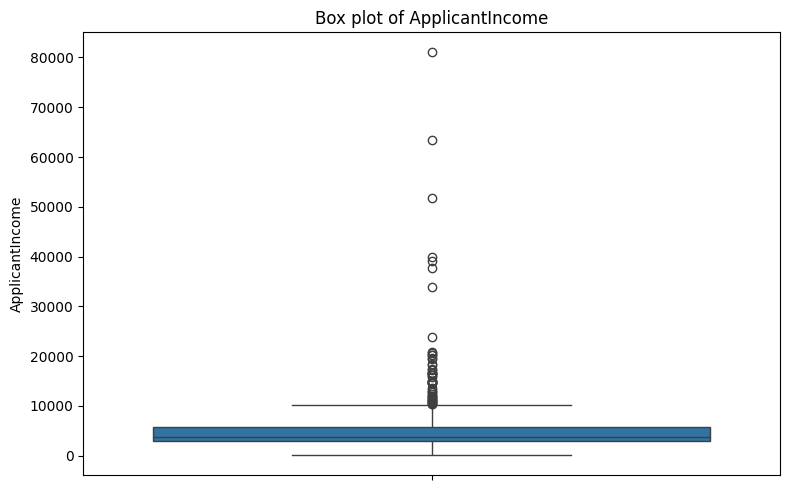

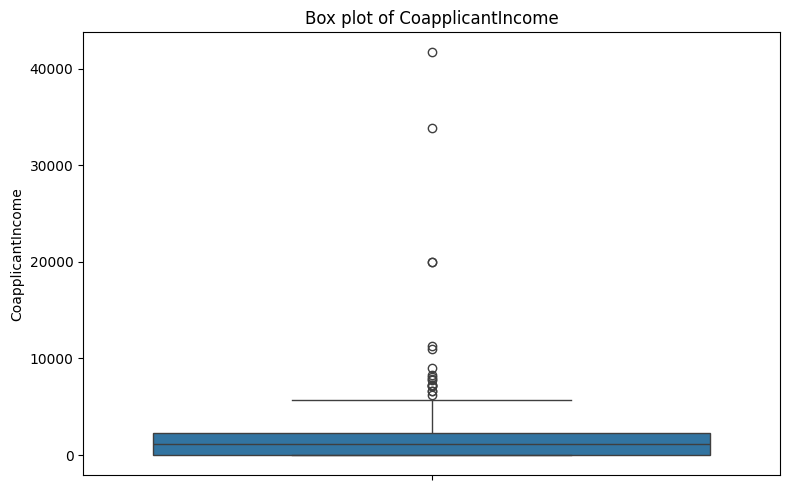

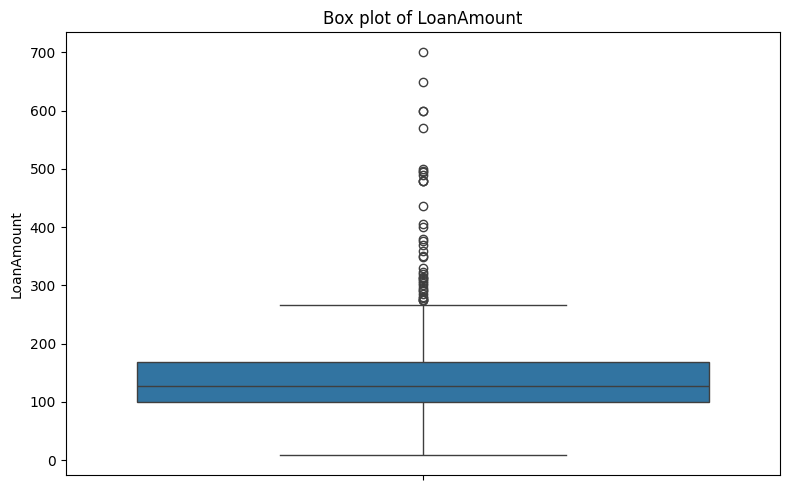

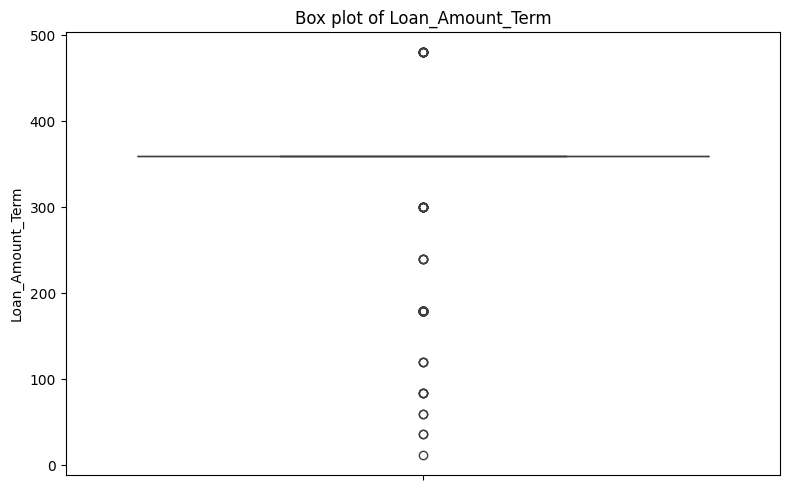

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in num_plot:
    fig, ax = plt.subplots(figsize=(8, 5))
    
    sns.boxplot(y=df[col], ax=ax)
    
    ax.set_title(f"Box plot of {col}")
    ax.set_ylabel(col)
    plt.tight_layout()
    plt.show()

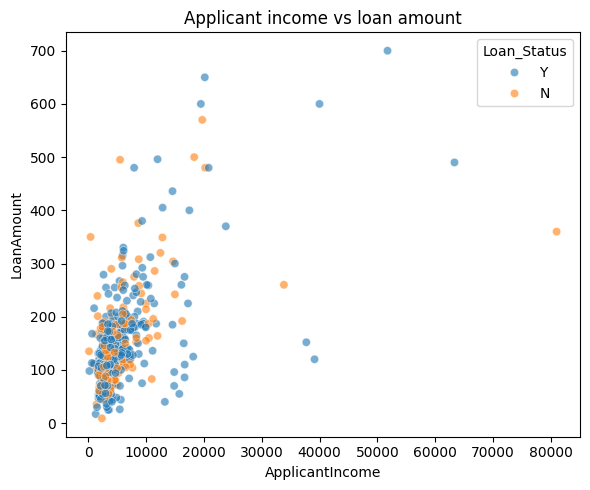

In [151]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(
    data=df,
    x="ApplicantIncome",
    y="LoanAmount",
    hue=target_col,
    alpha=0.6,
    ax=ax,
)
ax.set_title("Applicant income vs loan amount")
plt.tight_layout()
plt.show()

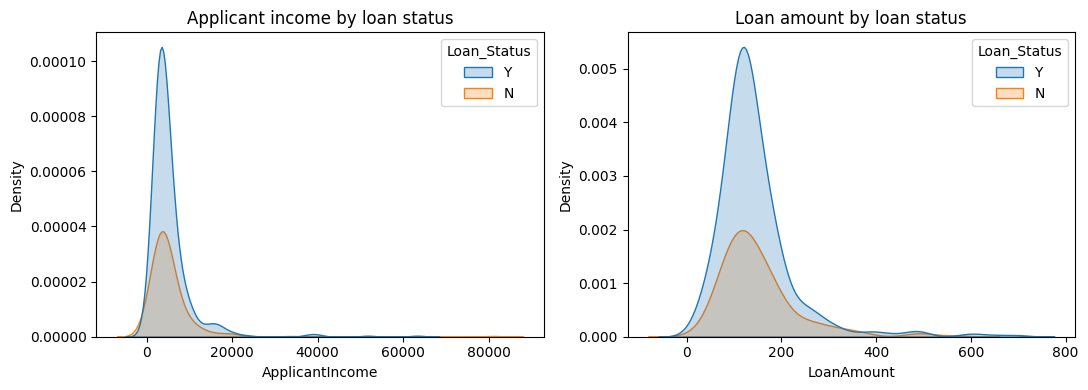

In [152]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.kdeplot(data=df, x="ApplicantIncome", hue=target_col, fill=True, ax=axes[0])
axes[0].set_title("Applicant income by loan status")
sns.kdeplot(data=df, x="LoanAmount", hue=target_col, fill=True, ax=axes[1])
axes[1].set_title("Loan amount by loan status")
plt.tight_layout()
plt.show()


In [153]:

features_to_check = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

for col in features_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[col] = np.where((df[col] < lower_bound) | (df[col] > upper_bound), np.nan, df[col])

print(f"Replaced outliers with NaN in: {features_to_check}")



Replaced outliers with NaN in: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']


--- Data Distributions AFTER handling outliers ---


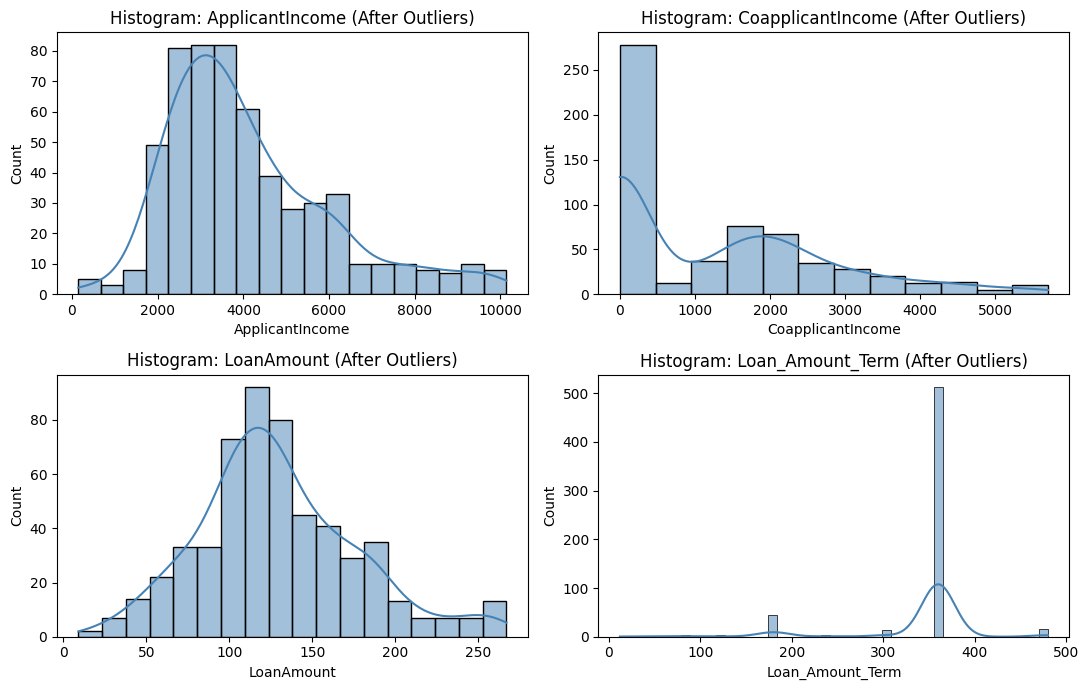

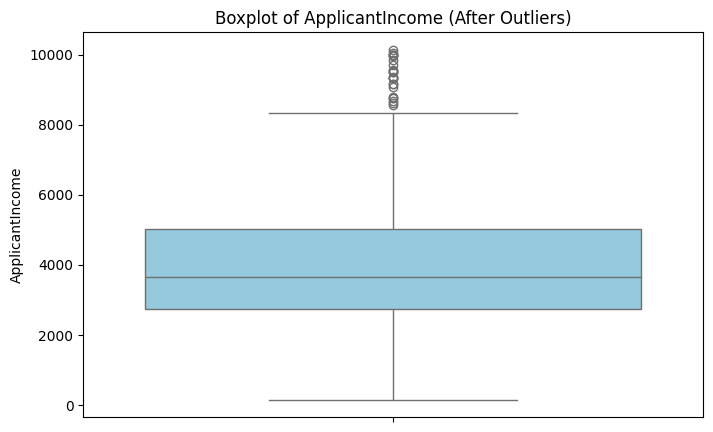

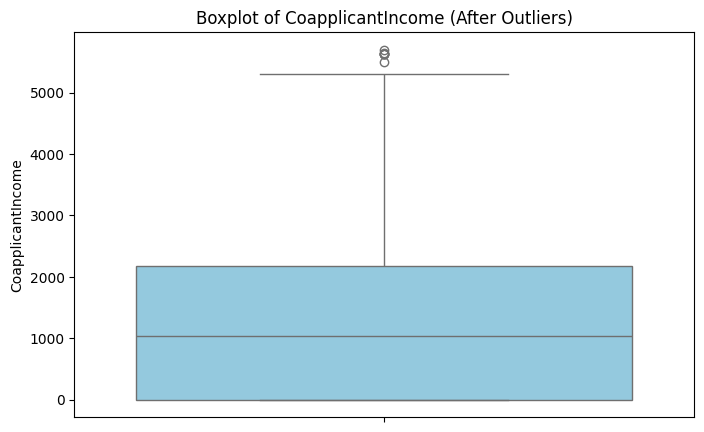

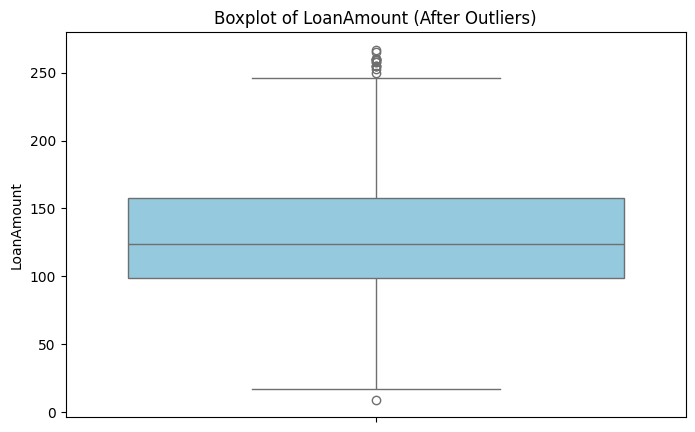

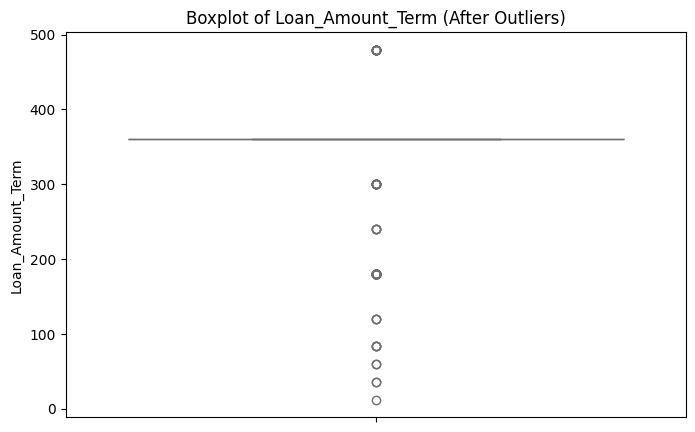

In [154]:
num_plot = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]
print("--- Data Distributions AFTER handling outliers ---")

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.ravel()
for ax, c in zip(axes, num_plot):
    sns.histplot(df[c].dropna(), kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Histogram: {c} (After Outliers)")
plt.tight_layout()
plt.show()

for c in num_plot:
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=df[c].dropna(), color="skyblue")
    plt.title(f"Boxplot of {c} (After Outliers)")
    plt.show()

## 7. Missing Value Imputation

In [ ]:
\
from sklearn.impute import SimpleImputer
num_imputer = SimpleImputer(strategy='median')
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

print("Missing values after median imputation:")
print(df[numeric_cols].isna().sum())


Missing values after median imputation:
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
dtype: int64


## 8. Correlation Analysis




Correlation matrix (numeric features + encoded target):


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Loan_Status_encoded
ApplicantIncome,1.000,-0.194,0.406,-0.036,0.016
CoapplicantIncome,-0.194,1.000,0.230,-0.005,0.041
LoanAmount,0.406,0.230,1.000,0.081,-0.027
Loan_Amount_Term,-0.036,-0.005,0.081,1.000,-0.023
Loan_Status_encoded,0.016,0.041,-0.027,-0.023,1.000


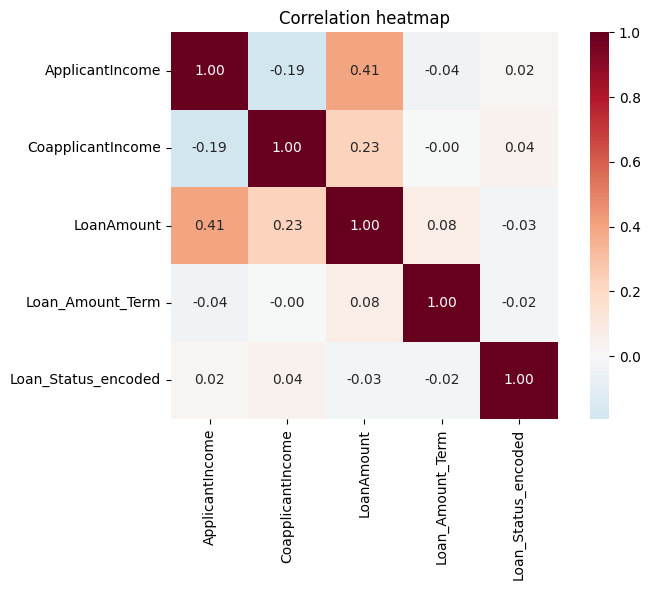

Strongest linear relationships with Loan_Status (encoded):
CoapplicantIncome    0.040781
LoanAmount          -0.026918
Loan_Amount_Term    -0.022549
ApplicantIncome      0.016339
Name: Loan_Status_encoded, dtype: float64


In [157]:
corr_cols = numeric_cols + ["Loan_Status_encoded"]

corr_df = df[corr_cols].corr(numeric_only=True)

print("Correlation matrix (numeric features + encoded target):")
display(corr_df.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

# Extract target correlation and sort it
target_corr = corr_df["Loan_Status_encoded"].drop("Loan_Status_encoded")
target_corr = target_corr.iloc[(-target_corr.abs()).argsort()]
print("Strongest linear relationships with Loan_Status (encoded):")
print(target_corr)


## 10. Data Standardization




In [ ]:

X_cols = [c for c in encoded_cat_names if c != "Loan_Status_encoded"] + numeric_cols
X = df[X_cols].copy()
y = df["Loan_Status_encoded"].copy()

print(f"Feature matrix X shape: {X.shape}")
print(f"Target y shape: {y.shape}")


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)




Feature matrix X shape: (614, 11)
Target y shape: (614,)


In [23]:
scaler = StandardScaler()
X_train_sc = X_train.copy()
X_test_sc = X_test.copy()
X_train_sc[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_sc[numeric_cols] = scaler.transform(X_test[numeric_cols])

display(X_train_sc.head(6))





,Gender_enc,Married_enc,Dependents_enc,Education_enc,Self_Employed_enc,Property_Area_enc,Credit_History_enc,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
154,1,0,0,0,0,2,1,-0.477068,-0.867409,-1.710475,0.280691
239,1,1,1,0,0,1,1,-0.443901,-0.867409,-0.715989,0.280691
448,1,1,2,0,0,0,0,-0.430308,0.321718,0.451451,0.280691
471,1,1,1,1,0,0,0,-0.803838,0.175685,-0.348462,-2.486768
273,1,1,0,0,0,1,1,-0.821781,0.678456,0.451451,0.280691
71,1,1,2,1,1,1,1,-1.226846,0.436458,-0.694370,0.280691


In [24]:
y_train

154    1
239    1
448    0
471    0
273    1
      ..
222    1
349    1
26     1
96     1
354    1
Name: Loan_Status_encoded, Length: 491, dtype: int64